In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"Bridges's drama about a reporter who discovers some flaws in the safety precautions taken at a nuclear powerplant is directed well and a pretty interesting film from the late 70s. Its not amazing, but its solid, the acting is pretty good especially Jack lemmon, but Douglas and Fonda were good too. It was a pretty good screenplay and Bridges's direction was solid and suitable. This is definitely not one of the best films of the 70s, but its one of the better ones. A good early Michael Douglas film and Lemmon in his prime.--- IMDb Rating: 7.2, my rating:, so in simple words, solid but not amazing... thats what this film is, solid but not amazing 8/10"

In [5]:
print(preprocess(df.iloc[random_num]['review']))

bridge drama reporter discovers flaw safety precaution taken nuclear powerplant directed well pretty interesting film late amazing solid acting pretty good especially jack lemmon douglas fonda good pretty good screenplay bridge direction solid suitable definitely one best film one better one good early michael douglas film lemmon prime imdb rating rating simple word solid amazing film solid amazing


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,921 (320.00 KB)

 Trainable params: 81,921 (320.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [15]:
"""lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

'lstm_history = lstm_model.fit(\n    X_train_pad, y_train,\n    epochs=100,\n    batch_size=128,   \n    validation_split=0.2,\n    callbacks=[early_stop, reduce_lr],\n    verbose=1\n)'

In [16]:
#lstm_model.save_weights("lstm_modelo_pesado.weights.h5")

In [17]:

lstm_model.load_weights("lstm_modelo_pesado.weights.h5")

c:\Users\jose.sales\AppData\Local\miniconda3\envs\ilumpy\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [19]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8798 - loss: 0.2872
Test Accuracy: 0.879800021648407


# Matriz de Confusão

#### Acurácia de 0.8798

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


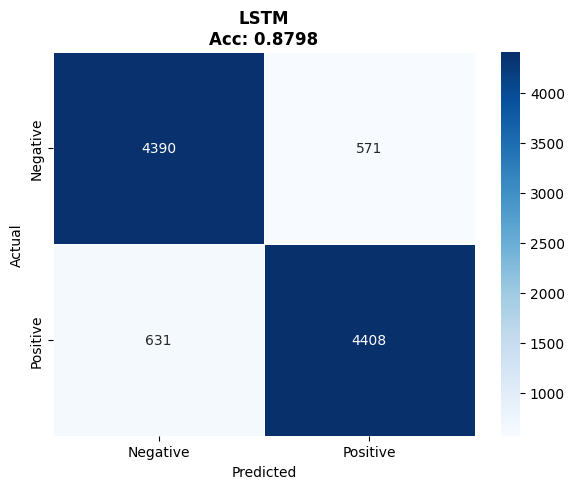

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [21]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.88      4961
    Positive       0.89      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Teste de Outputs


In [22]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Exportação de Pesos

In [23]:
export_weights(lstm_model, mode='lstm', output_file="pesos_8_24.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = -0.109018
  addr=0x08001 Wx_input[0][1] = -0.199980
  addr=0x08080 Wx_input[1][0] = -0.076865
  addr=0x08081 Wx_input[1][1] = 0.322674
  addr=0x08040 Wh_input[0][0] = 0.096314
  addr=0x08041 Wh_input[0][1] = 0.096670
  addr=0x080C0 Wh_input[1][0] = -0.257084
  addr=0x080C1 Wh_input[1][1] = 0.027510
  addr=0x18000 bias_input[0] = 0.105483
  addr=0x18080 bias_input[1] = 0.065706
  addr=0x0A000 Wx_forget[0][0] = 0.055015
  addr=0x0A001 Wx_forget[0][1] = 0.304638
  addr=0x0A080 Wx_forget[1][0] = 0.096081
  addr=0x0A081 Wx_forget[1][1] = -0.091311
  addr=0x0A040 Wh_forget[0][0] = -0.031453
  addr=0x0A041 Wh_forget[0][1] = -0.048669
  addr=0x0A0C0 Wh_forget[1][0] = -0.130194
  addr=0x0A0C1 Wh_forget[1][1] = 0.016035
  addr=0x1A000 bias_forget[0] = 1.089382
  addr=0x1A080 bias_forget[1] = 1.051004
  addr=0x0C000 Wx_candidate[0][0] = -0.378126
  addr=0x

# Teste Global

In [24]:
FRAC = 24  # ALTERADO DE 16 PARA 24
SCALE = 1 << FRAC  # 2^24 = 16777216

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q8(val):
    """Converte float para Q8.24 (formato signed 32 bits)"""
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [25]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q8 = float_to_q8(valor)  # sua função original
            mem[addr] = valor_q8
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q8(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [26]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 10

valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
Arquivo salvo: Global Processing/dados_0.mem
0 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Arquivo salvo: Global Processing/dados_1.mem
1 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Arquivo salvo: Global Processing/dados_2.mem
2 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Arquivo salvo: Global Processing/dados_3.mem
3 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Arquivo salvo: Global Processing/dados_4.mem
4 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Arquivo salvo: Global Processing/dados_5.mem
5 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Arquivo salvo: Global Processing/dados_6.mem
6 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Arquivo salvo: Global Processing/dados_7.mem
7 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Arquivo salvo: Global Processing/dados_8.mem
8 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Arquivo salvo: Global Processing/dados_9.mem
9 de 10


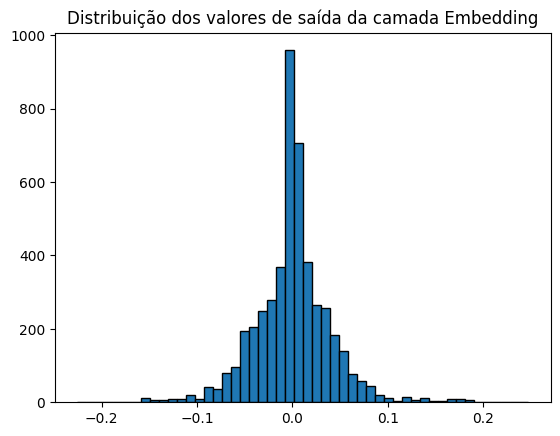

In [27]:
plt.title("Distribuição dos valores de saída da camada Embedding")
plt.hist(valores_out_embbeding, bins=50, edgecolor='black')
plt.show()

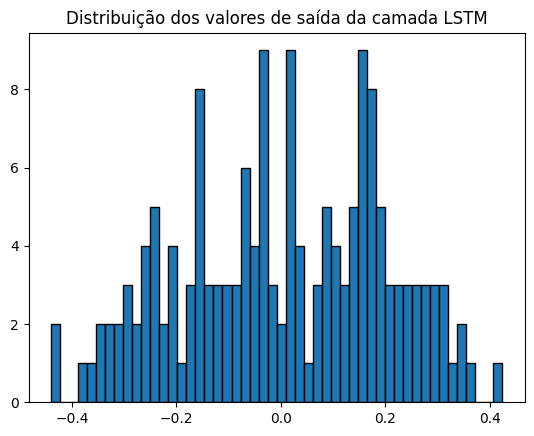

In [28]:
plt.title("Distribuição dos valores de saída da camada LSTM")
plt.hist(valores_out_lstm, bins=50, edgecolor='black')
plt.show()

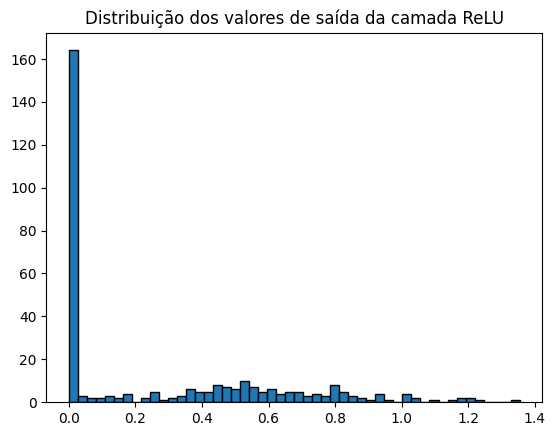

In [29]:
plt.title("Distribuição dos valores de saída da camada ReLU")
plt.hist(valores_out_relu, bins=50, edgecolor='black')
plt.show()

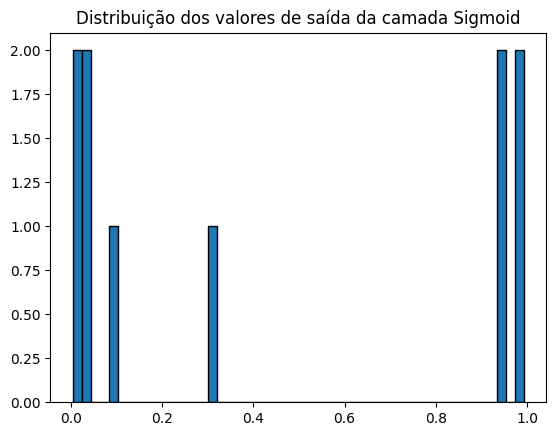

In [30]:
plt.title("Distribuição dos valores de saída da camada Sigmoid")
plt.hist(valores_out_sigmoid, bins=50, edgecolor='black')
plt.show()